# SARSA Algorithm

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement SARSA and compare with Q-learning
- Understand on-policy vs off-policy

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lesson 05 "Performing Sampling and Point Estimation" — an estimate is only valid for the distribution its samples came from, and that is precisely the on-policy / off-policy split: SARSA evaluates the policy that generated the data, Q-learning evaluates a greedier one it never followed.

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 2**.

---


## Lesson Brief

This lesson introduces **SARSA**, an on-policy alternative to Q-learning.

Students will compare how learning changes when updates depend on the action the agent actually follows, not only the greedy action estimate.

Why this matters: SARSA helps students understand that not all value-learning methods make the same assumptions about behavior and learning.

It is also a good lesson for discussing safer or more conservative learning behavior.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **deeplizard - "How to Code SARSA with Just Numpy"**:
[Watch on YouTube](https://www.youtube.com/watch?v=gJZwXkXDFEI)

Why this pick:
- coding-first explanation.
- Helps students see the on-policy nature of SARSA in a concrete update loop.
- Good companion when comparing SARSA against Q-learning.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- On-policy: learns from the actions actually taken by the current behavior policy.
- Next action: part of the SARSA update target.
- Behavior policy: the policy generating the data.
- Update target: the value the estimate moves toward.
- Exploration-aware learning: updates reflect the fact that the policy is still exploring.

### Quick Check
- Why does SARSA use the next chosen action?
- How can SARSA become more cautious?
- What makes SARSA on-policy?
- Why can exploration change the learned behavior itself?

### Common Mistakes
- Thinking SARSA equals Q-learning.
- Ignoring exploration in the update.
- Missing how the next action changes behavior.
- Forgetting that SARSA learns the value of the policy it is actually following.


## SARSA vs Q-Learning in Plain Language

Students often ask: if both algorithms update action values, why do we need both?

### Q-learning

Q-learning asks:

`What is the best next action I could take from the next state?`

So it learns toward a greedy target, even if the current behavior policy is still exploring.

### SARSA

SARSA asks:

`What action did I actually choose next, and what is its value?`

So the update includes the real next action produced by the current policy.

### Why does this matter?

If the current policy still explores, SARSA learns a value function that already reflects that exploration risk.
This often makes SARSA look more cautious than Q-learning.

### Memory trick

SARSA is named from the update pieces:

- State
- Action
- Reward
- State
- Action

That final action is the clue that the update depends on the next action actually taken.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- `gymnasium`'s **`CliffWalking-v1`** — the Gymnasium implementation of the cliff-walking task from
  Sutton & Barto's *Reinforcement Learning: An Introduction* (Example 6.6). A 4x12 grid, -1 per
  step, -100 for falling off the cliff.
- One training function that implements **both** algorithms, so SARSA and Q-learning differ by a
  single line and share every hyperparameter and random seed.

**Outputs:** What you'll see when you run the cells

- Each algorithm's greedy policy printed as a grid, with the route it actually walks marked.
- The measured average return of each during training, and one learning-curve figure.

---

### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Lesson opener: put the SARSA and Q-learning update targets side by side BEFORE any training.
# The whole lesson hangs on this one-line difference, so we print it where students start reading.

# Load the numeric and plotting libraries used by every later cell.
import numpy as np
import matplotlib.pyplot as plt

# Print the lesson banner.
print("=" * 70)
print("SARSA Algorithm")
print("=" * 70)

# The two temporal-difference update targets, written out in plain text.
print("\nBoth algorithms update:  Q(s,a) += alpha * (target - Q(s,a))")
print("\n  SARSA target      : r + gamma * Q(s', a')    <- a' = action ACTUALLY taken next")
print("  Q-learning target : r + gamma * max_a Q(s', a) <- best next action on paper")

# Name the on-policy / off-policy distinction the targets create.
print("\nSARSA is ON-policy: it learns about the policy it really follows, exploration included.")
print("Q-learning is OFF-policy: it learns about the greedy policy while still exploring.")
print("\nThe worked example below trains SARSA; the comparison section that follows")
print("trains Q-learning on the SAME environment so you can compare them directly.")


SARSA Algorithm

Both algorithms update:  Q(s,a) += alpha * (target - Q(s,a))

  SARSA target      : r + gamma * Q(s', a')    <- a' = action ACTUALLY taken next
  Q-learning target : r + gamma * max_a Q(s', a) <- best next action on paper

SARSA is ON-policy: it learns about the policy it really follows, exploration included.
Q-learning is OFF-policy: it learns about the greedy policy while still exploring.

The worked example below trains SARSA; the comparison section that follows
trains Q-learning on the SAME environment so you can compare them directly.


## 🌍 Worked Example — SARSA on the Cliff-Walking Benchmark

**Industry context:**
- Amazon uses RL to optimise warehouse robot routing
- Google DeepMind reduced data centre cooling costs by 40% using RL
- Uber uses RL for dynamic surge pricing

All three share a feature this benchmark captures exactly: the system keeps exploring **while it
is doing real work**, so a "risky but optimal" route can cost more than a safe, slightly longer one.

We use **`CliffWalking-v1`** from Gymnasium — the standard implementation of Sutton & Barto's
Example 6.6. Every step costs -1, so the agent wants the shortest path; but the shortest path runs
right along a cliff that costs -100 to fall into.

This is not a decorative choice of environment. On most small problems SARSA and Q-learning produce
nearly identical answers and the on-policy/off-policy distinction stays abstract. On the cliff, the
two algorithms learn **visibly different routes** — and you can see why.

### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Worked example: run SARSA on CliffWalking-v1, the benchmark this comparison was invented for.
# WHY it matters: SARSA and Q-learning differ by one symbol in the update, and on most small
# problems that difference is invisible. Sutton & Barto built the cliff-walking task (Example 6.6)
# precisely because it makes the difference impossible to miss - so we use the real Gymnasium
# version of it rather than a home-made grid.

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

env = gym.make("CliffWalking-v1")
N_STATES, N_ACTIONS = env.observation_space.n, env.action_space.n
ROWS, COLS = 4, 12
GOAL_STATE = 47
CLIFF_STATES = set(range(37, 47))

ALPHA, GAMMA, EPSILON = 0.5, 1.0, 0.1
N_EPISODES, STEP_CAP = 500, 200

print("Environment:", env.spec.id, f"| {ROWS}x{COLS} grid = {N_STATES} states, {N_ACTIONS} actions")
print("Reward rule: -1 for every step, -100 for stepping into the cliff (and back to start).")
print("So a good agent wants the SHORTEST path - but the shortest path runs along the cliff.\n")


def epsilon_greedy(q_row, rng):
    """Take a random action with probability EPSILON, otherwise the current best."""
    if rng.random() < EPSILON:
        return int(rng.integers(N_ACTIONS))
    return int(np.argmax(q_row))


def train(method, seed=1):
    """Train tabular SARSA or Q-learning. The ONLY difference is the TD target line below."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_ACTIONS))
    returns = []
    for ep in range(N_EPISODES):
        state, _ = env.reset(seed=int(seed * 10_000 + ep))
        action = epsilon_greedy(Q[state], rng)
        total = 0.0
        for _ in range(STEP_CAP):
            next_state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            # The next action the policy REALLY chooses - SARSA needs it, Q-learning ignores it.
            next_action = epsilon_greedy(Q[next_state], rng)
            if terminated:
                bootstrap = 0.0
            elif method == "sarsa":
                bootstrap = Q[next_state, next_action]     # on-policy: the action actually taken
            else:
                bootstrap = Q[next_state].max()            # off-policy: the best action on paper
            Q[state, action] += ALPHA * (reward + GAMMA * bootstrap - Q[state, action])
            state, action = next_state, next_action
            if terminated or truncated:
                break
        returns.append(total)
    return Q, np.array(returns)


def greedy_rollout(Q):
    """Follow the greedy policy from the start tile and return the states it visits."""
    state, _ = env.reset(seed=0)
    visited = [state]
    for _ in range(60):
        state, _, terminated, truncated, _ = env.step(int(np.argmax(Q[state])))
        visited.append(state)
        if terminated or truncated:
            break
    return visited


ARROWS = {0: "^", 1: ">", 2: "v", 3: "<"}


def show_grid(Q, title):
    """Print the greedy action per tile; [brackets] mark the path the agent actually walks."""
    path = set(greedy_rollout(Q))
    print(title)
    for row in range(ROWS):
        cells = []
        for col in range(COLS):
            s = row * COLS + col
            mark = "G" if s == GOAL_STATE else ("C" if s in CLIFF_STATES else ARROWS[int(np.argmax(Q[s]))])
            cells.append(f"[{mark}]" if s in path else f" {mark} ")
        print("   " + "".join(cells))
    print("   (C = cliff, G = goal, arrows = greedy action, [ ] = tiles the greedy policy walks)")


Q_sarsa, sarsa_returns = train("sarsa")
show_grid(Q_sarsa, "\nSARSA - greedy policy after training:")
print(f"\nSARSA average return over the last 100 training episodes: {sarsa_returns[-100:].mean():.2f}")
print("Look at which row the bracketed path uses - SARSA's answer to 'where should I walk?'")

Environment: CliffWalking-v1 | 4x12 grid = 48 states, 4 actions
Reward rule: -1 for every step, -100 for stepping into the cliff (and back to start).
So a good agent wants the SHORTEST path - but the shortest path runs along the cliff.


SARSA - greedy policy after training:
   [>][>][>][>][>][>][>][>][>][>][>][v]
   [^] ^  ^  ^  ^  ^  >  >  >  >  ^ [v]
   [^] ^  ^  ^  ^  ^  >  ^  ^  <  > [v]
   [^] C  C  C  C  C  C  C  C  C  C [G]
   (C = cliff, G = goal, arrows = greedy action, [ ] = tiles the greedy policy walks)

SARSA average return over the last 100 training episodes: -24.49
Look at which row the bracketed path uses - SARSA's answer to 'where should I walk?'


## Comparison — Q-Learning on the Same Cliff

SARSA above learned from the action it *actually* took next. Q-learning changes exactly one line:
the update target uses the **best** next action (`max`), whether or not the agent takes it.

The next cell reuses the same `train()` function, the same environment, the same hyperparameters
and the same seed. Only the `method` argument changes.

Watch two things:

- **which row of the grid** each greedy policy walks along
- **which algorithm collected more reward during training**

The surprise — and the reason this example is famous — is that those two answers point in opposite
directions.

### Step Guide

**What this cell does:** Trains **Q-learning** with the same environment, schedule and seed as the
SARSA run, prints both greedy policies as grids with their walked routes marked, and compares the
returns both actually collected while training.

**How to read it (weak Python OK):** Find the single changed line in `train()` —
`Q[next_state].max()` instead of `Q[next_state, next_action]`. Everything else is shared code.

**What to expect in the output:** Two 4x12 grids showing different routes, a step count for each
route, two average returns, and one figure with both learning curves.

**If you feel lost:** Just compare the two grids. One route hugs the cliff edge; the other detours
away from it. Then read which one scored better *during training* — that mismatch is the lesson.

SARSA (on-policy) - greedy policy:
   [>][>][>][>][>][>][>][>][>][>][>][v]
   [^] ^  ^  ^  ^  ^  >  >  >  >  ^ [v]
   [^] ^  ^  ^  ^  ^  >  ^  ^  <  > [v]
   [^] C  C  C  C  C  C  C  C  C  C [G]
   (C = cliff, G = goal, arrows = greedy action, [ ] = tiles the greedy policy walks)

Q-learning (off-policy) - greedy policy:
    <  v  ^  >  v  >  >  >  >  >  >  v 
    >  >  >  v  v  >  >  >  v  v  v  v 
   [>][>][>][>][>][>][>][>][>][>][>][v]
   [^] C  C  C  C  C  C  C  C  C  C [G]
   (C = cliff, G = goal, arrows = greedy action, [ ] = tiles the greedy policy walks)

Greedy path length  - SARSA: 17 steps | Q-learning: 13 steps
Average return over the last 100 TRAINING episodes (epsilon still 0.1):
   SARSA      :  -24.49
   Q-learning :  -47.96


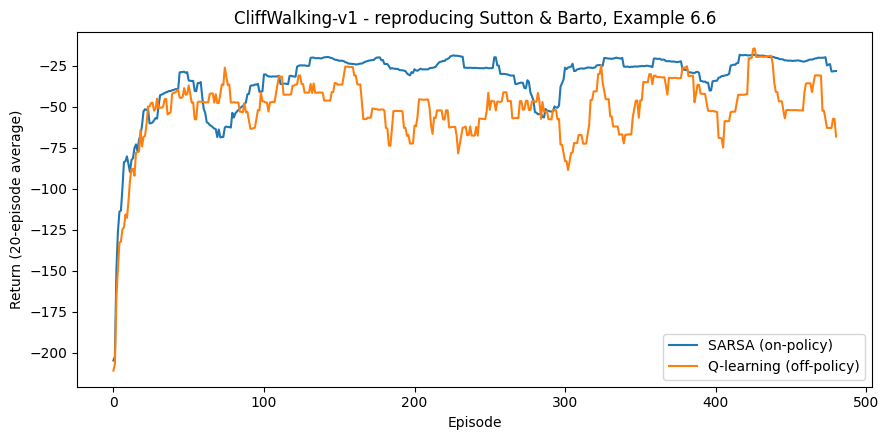


Mean grid row walked - SARSA: 0.67 | Q-learning: 2.14
(row 3 is the cliff row, row 2 runs right along its edge, row 0 is the far safe side)

What the measured numbers say:
- Q-learning's greedy path hugs the cliff. It is the OPTIMAL path: the shortest route.
- SARSA's greedy path detours away from the edge. It is longer, so it is NOT optimal.
- And yet SARSA collected MORE reward while training (-24.49 vs -47.96).
  This is the whole point of the lesson, and it is not a contradiction:
  * Q-learning's TD target assumes the next action will be the greedy one.
    But the agent is still epsilon-greedy, so 10% of the time it steps randomly -
    and one random step next to a cliff costs -100. Q-learning learns the value of
    a policy it is not actually following.
  * SARSA's target uses the action it really takes, so the exploration risk is priced
    into the values. It learns that walking beside a cliff while still exploring is
    expensive, and routes around it.

Rule of thumb: if 

In [3]:
# Comparison: train Q-LEARNING on the SAME environment with the SAME settings and seed.
# WHY it matters: exactly one line changed (max instead of the action actually taken). Everything
# else - environment, learning rate, epsilon, episode count, seed - is identical, so any difference
# in the result belongs to that one line and nothing else.

Q_qlearn, qlearn_returns = train("qlearning")

show_grid(Q_sarsa, "SARSA (on-policy) - greedy policy:")
print()
show_grid(Q_qlearn, "Q-learning (off-policy) - greedy policy:")

sarsa_path = greedy_rollout(Q_sarsa)
qlearn_path = greedy_rollout(Q_qlearn)
sarsa_late = sarsa_returns[-100:].mean()
qlearn_late = qlearn_returns[-100:].mean()

print(f"\nGreedy path length  - SARSA: {len(sarsa_path) - 1} steps | Q-learning: {len(qlearn_path) - 1} steps")
print(f"Average return over the last 100 TRAINING episodes (epsilon still 0.1):")
print(f"   SARSA      : {sarsa_late:7.2f}")
print(f"   Q-learning : {qlearn_late:7.2f}")

window = 20
plt.figure(figsize=(9, 4.5))
plt.plot(np.convolve(sarsa_returns, np.ones(window) / window, mode="valid"), label="SARSA (on-policy)")
plt.plot(np.convolve(qlearn_returns, np.ones(window) / window, mode="valid"), label="Q-learning (off-policy)")
plt.xlabel("Episode")
plt.ylabel(f"Return ({window}-episode average)")
plt.title("CliffWalking-v1 - reproducing Sutton & Barto, Example 6.6")
plt.legend(); plt.tight_layout(); plt.show()

# Which row does each greedy path spend most of its time in? Row 2 hugs the cliff, row 0 is safe.
sarsa_rows = [s // COLS for s in sarsa_path]
qlearn_rows = [s // COLS for s in qlearn_path]
print(f"\nMean grid row walked - SARSA: {np.mean(sarsa_rows):.2f} | Q-learning: {np.mean(qlearn_rows):.2f}")
print("(row 3 is the cliff row, row 2 runs right along its edge, row 0 is the far safe side)")

print("\nWhat the measured numbers say:")
if np.mean(qlearn_rows) > np.mean(sarsa_rows):
    print("- Q-learning's greedy path hugs the cliff. It is the OPTIMAL path: the shortest route.")
    print("- SARSA's greedy path detours away from the edge. It is longer, so it is NOT optimal.")
if sarsa_late > qlearn_late:
    print(f"- And yet SARSA collected MORE reward while training ({sarsa_late:.2f} vs {qlearn_late:.2f}).")
    print("  This is the whole point of the lesson, and it is not a contradiction:")
    print("  * Q-learning's TD target assumes the next action will be the greedy one.")
    print("    But the agent is still epsilon-greedy, so 10% of the time it steps randomly -")
    print("    and one random step next to a cliff costs -100. Q-learning learns the value of")
    print("    a policy it is not actually following.")
    print("  * SARSA's target uses the action it really takes, so the exploration risk is priced")
    print("    into the values. It learns that walking beside a cliff while still exploring is")
    print("    expensive, and routes around it.")
print("\nRule of thumb: if exploration continues while the agent is doing real work (a robot, a")
print("live system), the on-policy value is the one you actually experience. If you will train")
print("first and deploy a purely greedy policy afterwards, Q-learning's optimal path is the one")
print("you want. Same algorithm family, different question - so pick the one that matches yours.")

In [4]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Rummery, G. A. & Niranjan, M. (1994). *On-line Q-learning Using Connectionist Systems* (the SARSA report). Technical Report CUED/F-INFENG/TR 166, Cambridge University Engineering Department.
2. Sutton, R. S. (1988). *Learning to Predict by the Methods of Temporal Differences*. Machine Learning, 3. <https://link.springer.com/article/10.1007/BF00115009>
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6.4, Sarsa: On-policy TD Control.
4. Murphy, K. (2024). *Reinforcement Learning: An Overview*. arXiv:2412.05265. <https://arxiv.org/abs/2412.05265>
"""))

## 📚 References

1. Rummery, G. A. & Niranjan, M. (1994). *On-line Q-learning Using Connectionist Systems* (the SARSA report). Technical Report CUED/F-INFENG/TR 166, Cambridge University Engineering Department.
2. Sutton, R. S. (1988). *Learning to Predict by the Methods of Temporal Differences*. Machine Learning, 3. <https://link.springer.com/article/10.1007/BF00115009>
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 6.4, Sarsa: On-policy TD Control.
4. Murphy, K. (2024). *Reinforcement Learning: An Overview*. arXiv:2412.05265. <https://arxiv.org/abs/2412.05265>


## 📝 Summary

You implemented **SARSA** and **Q-Learning** as one function with a single differing line, and ran
both on `CliffWalking-v1` — the Gymnasium version of Sutton & Barto's Example 6.6.

The measured result reproduces the textbook finding:

- **Q-learning** (off-policy) learned the **optimal** path, hugging the cliff edge. Its update
  target assumes the next action will be greedy.
- **SARSA** (on-policy) learned a **safer, longer** path. Its target uses the action really taken,
  so the cost of exploring next to a cliff is priced into the values.
- **SARSA collected more reward during training**, even though its path is not the optimal one —
  because the agent was still exploring, and Q-learning's optimal path is only optimal for an agent
  that has stopped.

### The takeaway

"Off-policy learns the optimal policy" and "off-policy performs better" are different claims. Which
algorithm you want depends on whether exploration continues while the agent is doing real work.
Both power real applications such as elevator scheduling, traffic-signal optimisation and
game-playing agents.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


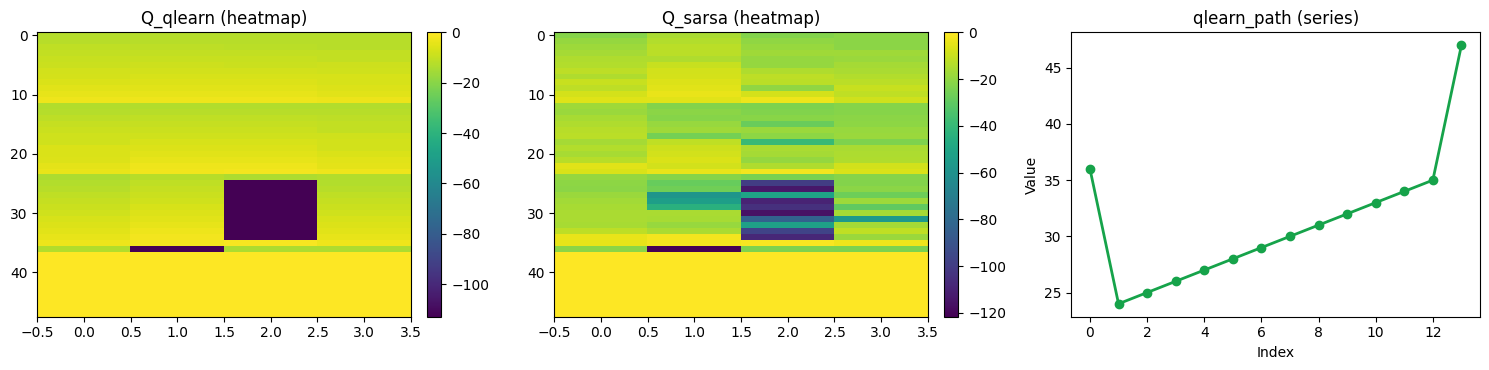

In [5]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** SARSA learns from the action the agent actually takes, so it reflects the behavior policy more directly than Q-learning does.

**If students remember one idea:** On-policy learning means the update follows the path the current policy really experienced.

**Quick check before moving on:**
- Can you explain the structural difference between the SARSA and Q-learning update targets?
- Can you describe why SARSA can behave more cautiously during exploration?

**Bridge to the next step:** After this comparison, students can better appreciate when prediction and control updates should reflect actual behavior versus greedy targets.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**At a glance:** The next cell uses a **random** policy on FrozenLake. **Not reaching the goal tile `G` is normal and intended**—the point is to see the **API loop** (state → action → reward → next state) in motion, not to prove a solved policy. If the episode ends in a hole or times out, the demo is still doing its job.

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.


Teaching note: random FrozenLake rollouts may not reach G—this is expected. Read state→action→reward over time, not 'did it win?'.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=4 | term=True | trunc=False


objc[65501]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x111e08138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1123049c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[65501]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x111e08188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112304a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[65501]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x111e07c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112304a68). T

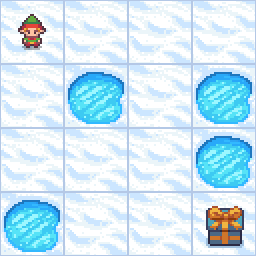

In [6]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

print(
    "Teaching note: random FrozenLake rollouts may not reach G—this is expected. "
    "Read state→action→reward over time, not 'did it win?'."
)

# Install the visual-demo dependencies quietly (safe to rerun; already-installed packages are skipped).
%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
